In [1]:
# Test script 4

In [1]:
import xarray as xr
import numpy as np

In [2]:
# === Path config ===
O3_DIR = "/glade/work/awells/air_quality/O3_obs/"
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"

In [13]:
# Open observations to use latitude and longitude values
o3 = xr.open_dataset(f"{O3_DIR}Delang_BME_OSDMA8_1990_2017.nc")["ozone"]

o3_lat = o3.latitude.values
o3_lon = o3.longitude.values

In [4]:
pop_orig = xr.open_dataset(f"{POP_DIR}ssp2_total_2010.nc4")["Band1"]

In [5]:
def expand_grid(pop_orig):
    # === Define resolution and bounds ===
    lat_res = 1 / 120  # 0.008333... degrees
    lon_res = 1 / 120
    
    # Generate full latitude and longitude ranges
    lat_full = np.arange(-90 + lat_res / 2, 90, lat_res)
    lon_full = np.arange(-180 + lon_res / 2, 180, lon_res)
    
    # Confirm lengths match your original grid
    print(f"Longitude points for pop_orig: {len(pop_orig.lon)},
          Longitude points: {len(lon_full)}")  # Should match lon: 43200
    
    # === Create new empty DataArray with NaNs ===
    pop_full = xr.DataArray(
        data=np.full((len(lat_full), len(lon_full)), np.nan),
        coords={"lat": lat_full, "lon": lon_full},
        dims=["lat", "lon"],
        name="population"
    )
    
    # === Add population data to empty DataArray ===
    # Find indices where original lat/lon match the full grid
    lat_idx = np.searchsorted(lat_full, pop_orig.lat.values)
    lon_idx = np.searchsorted(lon_full, pop_orig.lon.values)
    
    # Use advanced indexing to insert your data
    pop_full.values[np.ix_(lat_idx, lon_idx)] = pop_orig.values
    
    assert np.allclose(
        pop_full.sel(
            lat=pop_orig.lat, lon=pop_orig.lon, method="nearest", tolerance=1e-5
        ),
        pop_orig,
        equal_nan=True
    )

    return pop_full

Longitude points for pop_orig: 43200, Longitude points: 43200


In [6]:
pop_coarse = pop_full.coarsen(lat=12, lon=12).sum()

In [23]:
# From GBD “Aggregation to each 0.1 × 0.1 grid cell was accomplished by summing the central 12 × 12 population cells.”
pop_regrid = pop_full.coarsen(lat=12, lon=12).sum()

pop_lon = pop_regrid.lon.values
pop_lat = pop_regrid.lat.values

lat_mask = xr.ufuncs.logical_and(pop_lat <= o3_lat.max(),
                                 pop_lat >= o3_lat.min())
lon_mask = xr.ufuncs.logical_and(pop_lon <= o3_lon.max(),
                                 pop_lon >= o3_lon.min())
pop_mask = pop_regrid.sel(lat=lat_mask, lon=lon_mask)

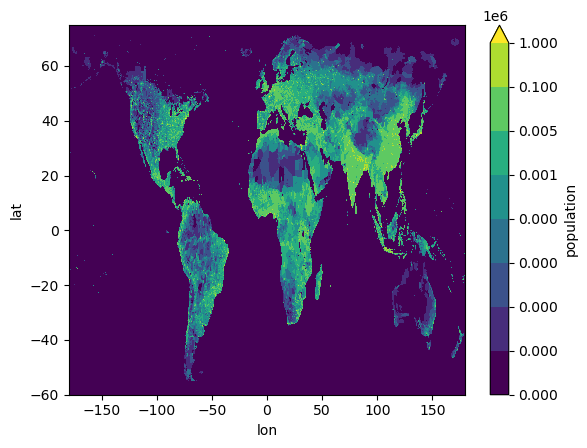

In [27]:
levels = [0, 1, 25, 100, 250, 1000, 5000, 100000, 1e6]
pop_mask.plot(levels=levels)